# Machine Learning Tutorial Python - 5: Dummy Variables & One Hot Encoding

Machine learning models work very well for dataset having only numbers. But how do we handle text information in dataset? Simple approach is to use interger or label encoding but when __categorical__ variables are __nominal__, using simple label encoding can be problematic. __One hot encoding__ is the technique that can help in this situation. In this tutorial, we will use __pandas get_dummies__ method to create dummy variables that allows us to perform one hot encoding on given dataset. Alternatively we can use __sklearn.preprocessing OneHotEncoder__ as well to create dummy variables. 

Code: https://github.com/codebasics/py/blob/master/ML/5_one_hot_encoding/one_hot_encoding.ipynb <br>
Credit: https://www.youtube.com/watch?v=9yl6-HEY7_s&list=PLeo1K3hjS3uvCeTYTeyfe0-rN5r8zn9rw&index=6
#### Owner: codebasics

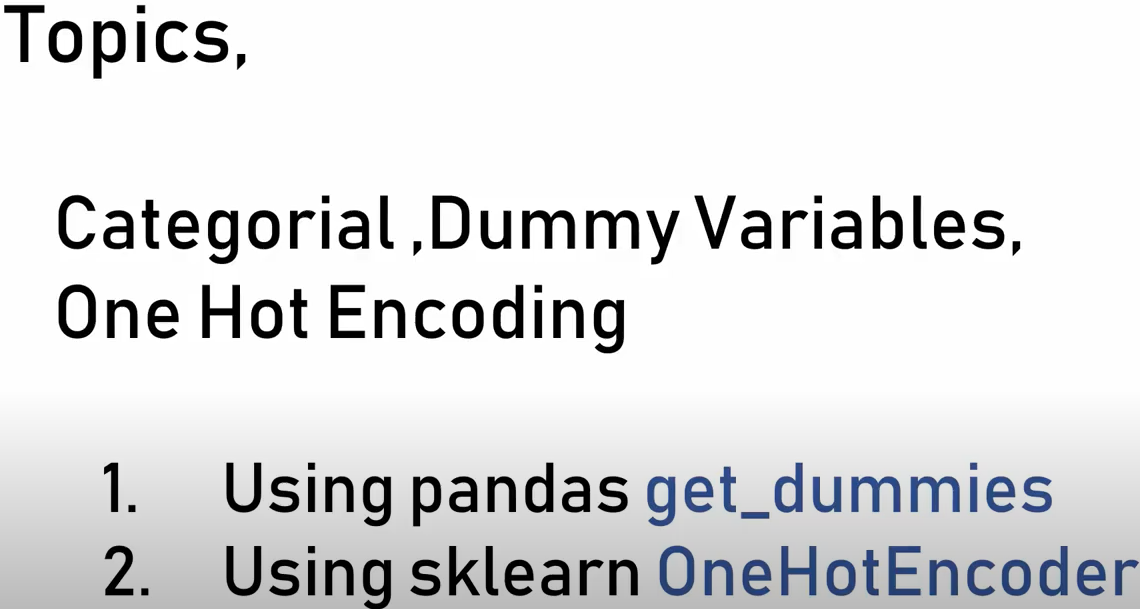

#### Build a predictor function to predict price of a home</br>
1. With 3400 sqrt ft area in west windsor
2. With 2800 sqrt ft area in robbinsville

### Categorical Variables and One Hot Encoding 

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('homeprices.csv')
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


### Using pandas to create dummy variables
handle the townname text data in numeric model

In [3]:
dummies = pd.get_dummies(df.town)
dummies

,monroe township,robinsville,west windsor
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,1,0


###  merge dummy and dataframe

In [4]:
merged = pd.concat([df, dummies], axis='columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,1,0,0
1,monroe township,3000,565000,1,0,0
2,monroe township,3200,610000,1,0,0
3,monroe township,3600,680000,1,0,0
4,monroe township,4000,725000,1,0,0
5,west windsor,2600,585000,0,0,1
6,west windsor,2800,615000,0,0,1
7,west windsor,3300,650000,0,0,1
8,west windsor,3600,710000,0,0,1
9,robinsville,2600,575000,0,1,0


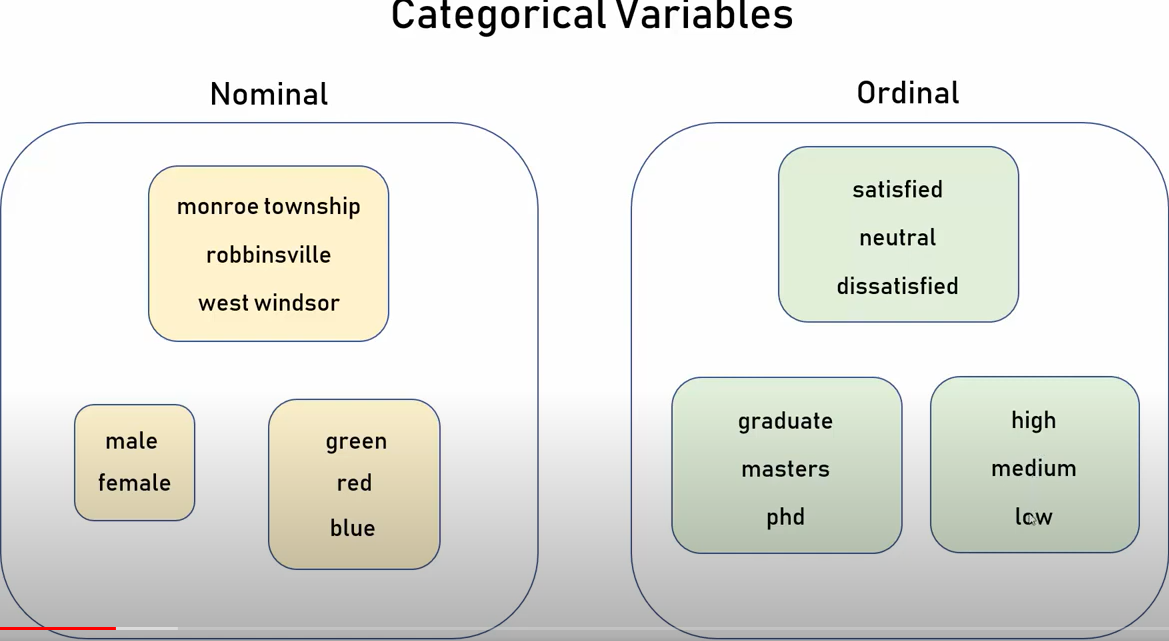

In [5]:
final = merged.drop(['town'], axis='columns')
final

,area,price,monroe township,robinsville,west windsor
0,2600,550000,1,0,0
1,3000,565000,1,0,0
2,3200,610000,1,0,0
3,3600,680000,1,0,0
4,4000,725000,1,0,0
5,2600,585000,0,0,1
6,2800,615000,0,0,1
7,3300,650000,0,0,1
8,3600,710000,0,0,1
9,2600,575000,0,1,0


### Dummy Variable Trap
When you can derive one variable from other variables, they are known to be __multi-colinear__. Here if you know values of __monroe township__ and __robinsville__ then you can easily infer the value of __west windsor__, i.e. __monroe township = 0__ and __robinsville = 0__. There for these state variables are called to be __multi-colinear__. In this situation linear regression won't work as expected. Hence you need to drop one column.

#### NOTE: sklearn library takes care of <font color='red'>"dummy variable trap"</font> hence even if you don't drop one of the state columns it is going to work, however we should make a habit of taking care of dummy variable trap ourselves just in case library that you are using is not handling this for you

In [6]:
final = final.drop(['west windsor'],axis='columns')
final

,area,price,monroe township,robinsville
0,2600,550000,1,0
1,3000,565000,1,0
2,3200,610000,1,0
3,3600,680000,1,0
4,4000,725000,1,0
5,2600,585000,0,0
6,2800,615000,0,0
7,3300,650000,0,0
8,3600,710000,0,0
9,2600,575000,0,1


In [7]:
X = final.drop('price',axis='columns') # independent variable
X

,area,monroe township,robinsville
0,2600,1,0
1,3000,1,0
2,3200,1,0
3,3600,1,0
4,4000,1,0
5,2600,0,0
6,2800,0,0
7,3300,0,0
8,3600,0,0
9,2600,0,1


In [8]:
y = final.price # dependent variable
y

0     550000
1     565000
2     610000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [9]:
model = LinearRegression()
model.fit(X,y) # let's now train the dataset

LinearRegression()

In [10]:
model.predict(X)

array([539709.7398409 , 590468.71640508, 615848.20468716, 666607.18125134,
       717366.15781551, 579723.71533005, 605103.20361213, 668551.92431735,
       706621.15674048, 565396.15136531, 603465.38378844, 628844.87207052,
       692293.59277574])

In [11]:
model.score(X,y)

0.9573929037221873

In [12]:
# 3400 sqr ft home in west windsor [0,0]. 
# It's mean west windsor is 1 (monroe township, robinsville, west windsor) and here we dropped "west windsor"
model.predict([[3400, 0, 0]]) 

array([681241.66845839])

In [13]:
model.predict([[2800,0,1]]) # 2800 sqr ft home in robbinsville

array([590775.63964739])

## Using sklearn OneHotEncoder
First step is to use **label encoder** to convert _town names_ into **numbers**

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # Encode target labels with value between 0 and n_classes-1.

In [15]:
dfle = df
dfle.town = le.fit_transform(dfle.town) # Fit label encoder and return encoded labels.
dfle

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [16]:
X = dfle[['town','area']].values # 'values' to get the output in array, 
# Only the values in the DataFrame will be returned, the axes labels will be removed.
X

array([[   0, 2600],
       [   0, 3000],
       [   0, 3200],
       [   0, 3600],
       [   0, 4000],
       [   2, 2600],
       [   2, 2800],
       [   2, 3300],
       [   2, 3600],
       [   1, 2600],
       [   1, 2900],
       [   1, 3100],
       [   1, 3600]], dtype=int64)

In [17]:
y = dfle.price.values # 'values' to get the output in array
y

array([550000, 565000, 610000, 680000, 725000, 585000, 615000, 650000,
       710000, 575000, 600000, 620000, 695000], dtype=int64)

### Now use one hot encoder to create dummy variables for each of the town 

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct_ohe = ColumnTransformer([('town',OneHotEncoder(),[0])],remainder='passthrough')
# transformers : list of tuples
#     List of (name, transformer, columns) tuples specifying the
#     transformer objects to be applied to subsets of the data.

# remainder : {'drop', 'passthrough'} or estimator, default='drop'
#     By default, only the specified columns in `transformers` are
#     transformed and combined in the output, and the non-specified
#     columns are dropped. (default of ``'drop'``).
#     By specifying ``remainder='passthrough'``, all remaining columns that
#     were not specified in `transformers` will be automatically passed
#     through. 

In [19]:
X = ct_ohe.fit_transform(X)
X
# Fit all transformers, transform the data and concatenate results.

# Parameters
# ----------
# X : {array-like, dataframe} of shape (n_samples, n_features)
#     Input data, of which specified subsets are used to fit the
#     transformers.

# y : array-like of shape (n_samples,), default=None
#     Targets for supervised learning.

array([[1.0e+00, 0.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.0e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.2e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 4.0e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.6e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.8e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.3e+03],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.9e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.1e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.6e+03]])

In [20]:
# drop a column to avoid dummy variable trap
X = X[:, 1:] # all rows included but in column, inclusion begins from the 1st and then include all columns
# Slicing [0th row : till nth row, 0th column : till nth column] 
X

array([[0.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 0.0e+00, 3.0e+03],
       [0.0e+00, 0.0e+00, 3.2e+03],
       [0.0e+00, 0.0e+00, 3.6e+03],
       [0.0e+00, 0.0e+00, 4.0e+03],
       [0.0e+00, 1.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 2.8e+03],
       [0.0e+00, 1.0e+00, 3.3e+03],
       [0.0e+00, 1.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 2.9e+03],
       [1.0e+00, 0.0e+00, 3.1e+03],
       [1.0e+00, 0.0e+00, 3.6e+03]])

In [21]:
model.fit(X,y) # train the model

LinearRegression()

In [22]:
# 3400 sqr ft home in west windsor. [monroe township, robinsville, west windsor] and here we dropped "monroe township"
model.predict([[0,1,3400]]) 

array([681241.6684584])

In [23]:
model.predict([[1,0,2800]]) # 2800 sqr ft home in robbinsville

array([590775.63964739])